# 06 — UMAP + HDBSCAN Clustering

**Пайплайн:**  
`Dataloader` → ручные признаки (11 фич на окно) → `RobustScaler` → `UMAPProjector` → `HDBSCANClusterer`

In [1]:
%load_ext autoreload
%autoreload 2

import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../../src"))
sys.path.insert(0, os.path.abspath("src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from data.dataloader import Dataloader
from data.tickers import TICKERS
from clustering.umap_reducer import UMAPProjector
from clustering.hdbscan import HDBSCANClusterer
from clustering.cluster_analyze import ClusterAnalyzer

WINDOW  = 60
STRIDE  = 5
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Признаки — точечные значения на последний день окна.
# Все вычисляются в loader.add_features(), имена совпадают с колонками DataFrame.
FEATURE_COLS = [
    "open", "high", "low", "close", "volume",
    "sma5", "sma20", "ema12", "ema26", "close_sma20",
    "macd", "macd_signal", "macd_hist", "rsi14",
    "bb_pct", "bb_bw", "atr14", "obv",
]
print(f"Window={WINDOW}, Stride={STRIDE}, Features={len(FEATURE_COLS)}")

245
Window=60, Stride=5, Features=18


In [2]:
loader = Dataloader()

dataset = loader.cut_on_windows(
    TICKERS,
    seq_len=WINDOW,
    step_size=STRIDE,
    feature_cols=FEATURE_COLS,
    path="../../src/data/moex_candles",
)
print(f"Loaded {len(dataset)} / {len(TICKERS)} tickers")

X_train, y_train, X_val, y_val, X_test, y_test = loader.concat_splits(dataset)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape}    y_val:   {y_val.shape}")
print(f"X_test:  {X_test.shape}   y_test:  {y_test.shape}")

Loaded 236 / 245 tickers
X_train: (114378, 60, 18)  y_train: (114378,)
X_val:   (19700, 60, 18)    y_val:   (19700,)
X_test:  (14310, 60, 18)   y_test:  (14310,)


In [3]:
# ── Flatten + StandardScaler ─────────────────────────────────────────────────
# X: (N, seq_len, n_features) → flatten → (N, seq_len * n_features)
# Так UMAP видит полную форму паттерна, а не только конечную точку.

F_train = X_train.reshape(len(X_train), -1)
F_val   = X_val.reshape(len(X_val),   -1)
F_test  = X_test.reshape(len(X_test),  -1)

scaler     = StandardScaler()
F_train_sc = scaler.fit_transform(F_train)
F_val_sc   = scaler.transform(F_val)
F_test_sc  = scaler.transform(F_test)

print(f"F_train: {F_train_sc.shape}  (flatten: {WINDOW} шагов × {len(FEATURE_COLS)} фич)")

F_train: (114378, 1080)  (flatten: 60 шагов × 18 фич)


PCA: минимальное число компонент для покрытия дисперсии:
   80%  →   24 компонент
   90%  →   79 компонент
   95%  →  150 компонент


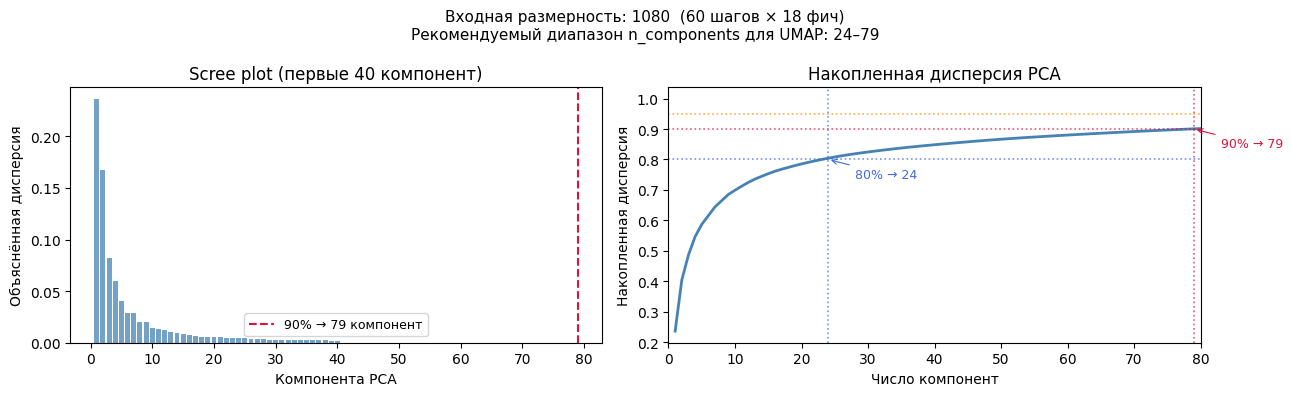


Рекомендуемый диапазон: 24–79 компонент
→ N_COMPONENTS = 79  (число компонент PCA, порог 90% дисперсии)
   Это НЕ n_components для UMAP — UMAP-размерность подбирается в Шаге 2б.


In [4]:
# ── Шаг 1: выбор числа компонент PCA ─────────────────────────────────────────
#
# PCA используется как первый шаг шумоподавления перед UMAP.
# Задача: выбрать сколько компонент PCA сохранить (N_COMPONENTS).
#
# Почему PCA перед UMAP:
#   • 1080D (60 шагов × 18 фич) — очень много шума и коррелированных признаков
#   • PCA линейно убирает шум: оставляем только главные направления дисперсии
#   • UMAP работает быстрее и точнее на ~80D, чем на 1080D
#
# UMAP при этом НЕ заменяется PCA — он по-прежнему ищет нелинейную структуру,
# но уже в очищенном пространстве.
#
# N_COMPONENTS = сколько PCA-компонент оставить (не связан с UMAP n_components!)
# UMAP n_components подбирается отдельно в Шаге 2б.

from sklearn.decomposition import PCA

pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(F_train_sc)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

thresholds = {0.80: "royalblue", 0.90: "crimson", 0.95: "darkorange"}
k_vals = {t: int(np.searchsorted(cum_var, t) + 1) for t in thresholds}

print("PCA: минимальное число компонент для покрытия дисперсии:")
for t, k in k_vals.items():
    print(f"  {int(t*100):>3}%  →  {k:>3} компонент")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Scree plot
axes[0].bar(range(1, 41), pca_full.explained_variance_ratio_[:40],
            color="steelblue", alpha=0.75, width=0.8)
axes[0].set_xlabel("Компонента PCA")
axes[0].set_ylabel("Объяснённая дисперсия")
axes[0].set_title("Scree plot (первые 40 компонент)")
axes[0].axvline(k_vals[0.90], color="crimson", ls="--", lw=1.5,
                label=f"90% → {k_vals[0.90]} компонент")
axes[0].legend(fontsize=9)

# Cumulative variance
axes[1].plot(range(1, len(cum_var) + 1), cum_var, lw=2, color="steelblue")
for t, color in thresholds.items():
    k = k_vals[t]
    axes[1].axhline(t, color=color, ls=":", lw=1.2, alpha=0.7)
    axes[1].axvline(k, color=color, ls=":", lw=1.2, alpha=0.7)
    axes[1].annotate(f"{int(t*100)}% → {k}",
                     xy=(k, t), xytext=(k + 4, t - 0.06),
                     fontsize=9, color=color,
                     arrowprops=dict(arrowstyle="->", color=color, lw=0.8))
axes[1].set_xlabel("Число компонент")
axes[1].set_ylabel("Накопленная дисперсия")
axes[1].set_title("Накопленная дисперсия PCA")
axes[1].set_xlim(0, 80)

plt.suptitle(
    f"Входная размерность: {F_train_sc.shape[1]}  "
    f"({WINDOW} шагов × {len(FEATURE_COLS)} фич)\n"
    f"Рекомендуемый диапазон n_components для UMAP: {k_vals[0.80]}–{k_vals[0.90]}",
    fontsize=11,
)
plt.tight_layout()
plt.show()

# ── Выбор N_COMPONENTS ───────────────────────────────────────────────────────
# Берём порог 90%: достаточно структуры, но не слишком много для HDBSCAN.
# При необходимости скорректируй вручную (рекомендуемый диапазон ниже).
N_COMPONENTS = k_vals[0.90]

print(f"\nРекомендуемый диапазон: {k_vals[0.80]}–{k_vals[0.90]} компонент")
print(f"→ N_COMPONENTS = {N_COMPONENTS}  (число компонент PCA, порог 90% дисперсии)")
print(f"   Это НЕ n_components для UMAP — UMAP-размерность подбирается в Шаге 2б.")

In [5]:
# ── Шаг 1б: применяем PCA ────────────────────────────────────────────────────
# N_COMPONENTS = число компонент PCA, определено в предыдущей ячейке.
# Результат P_train — очищенное пространство, которое идёт на вход в UMAP.
# PCA здесь — шумоподавление, а не финальное представление для кластеризации.

from sklearn.decomposition import PCA as _PCA

pca_pre = _PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
P_train = pca_pre.fit_transform(F_train_sc)
P_val   = pca_pre.transform(F_val_sc)
P_test  = pca_pre.transform(F_test_sc)

print(f"PCA:  {F_train_sc.shape}  →  {P_train.shape}")
print(f"Следующий шаг: подбор параметров UMAP →")

PCA:  (114378, 1080)  →  (114378, 79)
Следующий шаг: подбор параметров UMAP →


In [7]:
# ── Шаг 2: подбор параметров UMAP ────────────────────────────────────────────
#
# UMAP — снижение размерности (не кластеризация!).
# Задача UMAP: сжать P_train (79D) в Z_train (5–15D) так, чтобы
# HDBSCAN потом нашёл в этом пространстве хорошие кластеры.
#
# Подбираемые параметры:
#   n_neighbors:  число соседей для построения графа UMAP
#                 мало → локальная структура | много → глобальная
#   n_components: выходная размерность UMAP (Z_train будет shape (N, n_components))
#                 мало (5) → быстро, меньше информации
#                 много (15) → медленнее, сохраняет больше структуры
#
# Оценка: для каждого UMAP-вложения запускаем HDBSCAN с фиксированными
# параметрами и смотрим silhouette на HDBSCAN-метках.
# Хороший UMAP → плотные компактные кластеры → высокий silhouette.

import time
import importlib
import clustering.hdbscan as _hdb_mod
importlib.reload(_hdb_mod)
from clustering.hdbscan import HDBSCANClusterer
from sklearn.metrics import silhouette_score as _sil_score
from itertools import product

N_NEIGHBORS_GRID = [10]
N_UMAP_DIM_GRID  = [10]
EVAL_MCS         = 100   # фиксированный HDBSCAN только для оценки
EVAL_MS          = 5
SIL_SAMPLE       = 10_000

configs_umap = list(product(N_NEIGHBORS_GRID, N_UMAP_DIM_GRID))
print(f"UMAP конфигураций: {len(configs_umap)}\n")

umap_rows = []
for i, (nn, nd) in enumerate(configs_umap, 1):
    t0 = time.time()

    _reducer = UMAPProjector(
        n_components=nd, n_neighbors=nn, min_dist=0.0,
        metric="euclidean", scale=False, random_state=RANDOM_STATE,
    )
    Z_eval = _reducer.fit_transform(P_train)

    _h = HDBSCANClusterer(min_cluster_size=EVAL_MCS, min_samples=EVAL_MS,
                          scale=False, prediction_data=False)
    _h.fit(Z_eval)
    lbl, n_c = _h.labels_, _h.n_clusters_
    noise = _h.noise_ratio_ * 100

    sil = float("nan")
    if n_c >= 2:
        mask = lbl != -1
        if mask.sum() > 100:
            sil = round(_sil_score(Z_eval[mask], lbl[mask],
                                   sample_size=min(SIL_SAMPLE, mask.sum()),
                                   random_state=42), 4)

    elapsed = round(time.time() - t0, 1)
    umap_rows.append({"n_neighbors": nn, "n_components": nd,
                      "n_clusters": n_c, "noise_%": round(noise, 1),
                      "silhouette": sil, "time_s": elapsed})
    print(f"[{i:02d}/{len(configs_umap)}]  nn={nn:2d}  nd={nd:2d}  "
          f"→ {n_c:2d} cls  noise={noise:5.1f}%  sil={sil:.4f}  ({elapsed}s)")

df_umap_search = pd.DataFrame(umap_rows)

# Лучший по silhouette среди конфигов с ≥ 2 кластеров
best_umap = (df_umap_search[df_umap_search["n_clusters"] >= 2]
             .sort_values("silhouette", ascending=False).iloc[0])

BEST_N_NEIGHBORS = int(best_umap["n_neighbors"])
BEST_UMAP_DIM    = int(best_umap["n_components"])

print(f"\n{'═'*60}")
print(f"→ Лучший UMAP: n_neighbors={BEST_N_NEIGHBORS}, n_components={BEST_UMAP_DIM}")
print(f"  ({int(best_umap['n_clusters'])} кластеров, "
      f"шум={best_umap['noise_%']:.1f}%, sil={best_umap['silhouette']:.4f})")

display(df_umap_search.sort_values("silhouette", ascending=False)
        .reset_index(drop=True)
        .style.format({"noise_%": "{:.1f}", "silhouette": "{:.4f}", "time_s": "{:.1f}"})
        .set_caption("Сортировка по silhouette ↓"))

UMAP конфигураций: 1

[01/1]  nn=10  nd=10  →  2 cls  noise= 25.5%  sil=-0.1632  (116.1s)

════════════════════════════════════════════════════════════
→ Лучший UMAP: n_neighbors=10, n_components=10
  (2 кластеров, шум=25.5%, sil=-0.1632)


,n_neighbors,n_components,n_clusters,noise_%,silhouette,time_s
0,10,10,2,25.5,-0.1632,116.1


In [8]:
# ── Шаг 2б: финальный UMAP ───────────────────────────────────────────────────
# Запускаем UMAP с лучшими параметрами из поиска выше.
# Результат Z_train — пространство для HDBSCAN, Z2_train — для визуализации.
#
# При желании переопределить вручную:
# BEST_N_NEIGHBORS = 20
# BEST_UMAP_DIM    = 10

umap_clust = UMAPProjector(
    n_components=BEST_UMAP_DIM, n_neighbors=BEST_N_NEIGHBORS, min_dist=0.0,
    metric="euclidean", scale=False, random_state=RANDOM_STATE,
)
Z_train = umap_clust.fit_transform(P_train)
Z_val   = umap_clust.transform(P_val)
Z_test  = umap_clust.transform(P_test)

umap_vis = UMAPProjector(
    n_components=2, n_neighbors=BEST_N_NEIGHBORS, min_dist=0.1,
    metric="euclidean", scale=False, random_state=RANDOM_STATE,
)
Z2_train = umap_vis.fit_transform(P_train)

print(f"UMAP {BEST_UMAP_DIM}D (кластеризация): {Z_train.shape}")
print(f"UMAP  2D (визуализация):  {Z2_train.shape}")

UMAP 10D (кластеризация): (114378, 10)
UMAP  2D (визуализация):  (114378, 2)


In [9]:
train_end = loader.split.train_end
tickers_list, ts_list = [], []
for ticker, splits in dataset.items():
    X_t, _ = splits["train"]
    n_w = len(X_t)
    for i in range(n_w):
        days_back = (n_w - 1 - i) * STRIDE
        w_end = train_end - pd.Timedelta(days=int(days_back * 1.4))
        tickers_list.append(ticker)
        ts_list.append(w_end)

tickers_train    = np.array(tickers_list)
timestamps_train = np.array(ts_list)

# ── Медианы признаков (нужны ниже для RegimeInterpreter) ─────────────────────
CLOSE_IDX = FEATURE_COLS.index("close")
feat_df   = pd.DataFrame(X_train[:, -1, :], columns=FEATURE_COLS)
feat_df["cluster"] = labels_train
medians   = feat_df[feat_df["cluster"] != -1].groupby("cluster")[FEATURE_COLS].median()

# ── ClusterAnalyzer ───────────────────────────────────────────────────────────
analyzer = ClusterAnalyzer(
    labels=labels_train,
    windows=X_train,
    embeddings=Z_train,
    timestamps=timestamps_train,
    tickers=tickers_train,
    close_idx=CLOSE_IDX,
    feature_names=FEATURE_COLS,
)

NameError: name 'labels_train' is not defined

In [ ]:
# ── Перебор параметров HDBSCAN (цель: шум < 15%) ─────────────────────────────
#
# Как параметры влияют на шум:
#
#   min_samples ↓          → легче стать "ядровой точкой" → МЕНЬШЕ шума
#                            (самый прямой рычаг!)
#
#   cluster_selection_epsilon ↑  → объединяет кластеры в радиусе epsilon
#                                  → меньше кластеров, граничные точки
#                                    прибиваются к ближайшему кластеру
#                                    → МЕНЬШЕ шума
#
#   min_cluster_size ↑     → меньше кластеров, но крупнее; мелкие группы
#                            идут в шум → БОЛЬШЕ шума при малых значениях,
#                            но на очень больших значениях шум снова растёт
#
#   cluster_selection_method = 'leaf' → всегда >> 50% шума, убираем из grid

import time, importlib
from itertools import product
from sklearn.metrics import silhouette_score as _sil_score

import clustering.hdbscan as _hdb_mod
importlib.reload(_hdb_mod)
from clustering.hdbscan import HDBSCANClusterer

# ── Grid ──────────────────────────────────────────────────────────────────────
MIN_CLUSTER_SIZE_GRID = [300]
MIN_SAMPLES_GRID      = [1, 3, 5, 10]          # ключевой рычаг шума
EPSILON_GRID          = [0.5]   # объединяет близкие кластеры
# leaf убран — стабильно даёт > 75% шума
NOISE_LIMIT           = 15.0
MIN_CLUSTERS          = 2
MAX_CLUSTERS          = 12
SIL_SAMPLE            = 20_000

configs = list(product(MIN_CLUSTER_SIZE_GRID, MIN_SAMPLES_GRID, EPSILON_GRID))
print(f"Конфигураций: {len(configs)} (все с method='eom')\n")

rows = []
for i, (mcs, ms, eps) in enumerate(configs, 1):
    t0 = time.time()
    h = HDBSCANClusterer(
        min_cluster_size=mcs,
        min_samples=ms,
        cluster_selection_epsilon=eps,
        cluster_selection_method="eom",
        scale=False,
        prediction_data=False,
    )
    h.fit(Z_train)
    elapsed = time.time() - t0

    lbl   = h.labels_
    n_c   = h.n_clusters_
    noise = h.noise_ratio_ * 100
    ok    = (noise <= NOISE_LIMIT) and (MIN_CLUSTERS <= n_c <= MAX_CLUSTERS)

    sil = float("nan")
    if n_c >= MIN_CLUSTERS:
        mask = lbl != -1
        if mask.sum() > 100 and len(np.unique(lbl[mask])) >= 2:
            n_samp = min(SIL_SAMPLE, int(mask.sum()))
            sil = round(_sil_score(Z_train[mask], lbl[mask],
                                   sample_size=n_samp, random_state=42), 4)

    rows.append({
        "min_cluster_size":          mcs,
        "min_samples":               ms,
        "cluster_selection_epsilon": eps,
        "n_clusters":                n_c,
        "noise_%":                   round(noise, 1),
        "silhouette":                sil,
        "_ok":                       ok,
        "time_s":                    round(elapsed, 1),
    })
    flag = "✓" if ok else (" " if n_c >= MIN_CLUSTERS else "✗")
    print(f"[{i:03d}/{len(configs)}] {flag}  "
          f"mcs={mcs:5d}  ms={ms:2d}  eps={eps:.1f}  "
          f"→ {n_c:3d} cls  noise={noise:5.1f}%  sil={sil:.4f}  ({elapsed:.1f}s)")

# ── Итоговая таблица ──────────────────────────────────────────────────────────
df_sweep = pd.DataFrame(rows)
noise_ok = df_sweep["noise_%"] <= NOISE_LIMIT
clust_ok = (df_sweep["n_clusters"] >= MIN_CLUSTERS) & (df_sweep["n_clusters"] <= MAX_CLUSTERS)
good     = (noise_ok & clust_ok).values

print(f"\n{'═'*72}")
print(f"Конфигов с noise ≤ {NOISE_LIMIT}%:           {noise_ok.sum()} из {len(configs)}")
print(f"Конфигов с {MIN_CLUSTERS}–{MAX_CLUSTERS} кластеров:         {clust_ok.sum()} из {len(configs)}")
print(f"Прошли оба условия (зелёный): {good.sum()}")

def _row_style(row):
    if good[row.name]:
        return ["background-color: #d4edda"] * len(row)
    if clust_ok.iloc[row.name]:
        return ["background-color: #fff3cd"] * len(row)
    return [""] * len(row)

display(
    df_sweep.drop(columns="_ok")
    .sort_values(["noise_%", "silhouette"], ascending=[True, False])
    .reset_index(drop=True)
    .style
    .apply(_row_style, axis=1)
    .format({"noise_%": "{:.1f}", "silhouette": "{:.4f}", "time_s": "{:.1f}"})
    .set_caption(
        f"Зелёный = noise ≤ {NOISE_LIMIT}% И {MIN_CLUSTERS}–{MAX_CLUSTERS} кластеров  |  "
        f"Жёлтый = кластеры OK, но шум > {NOISE_LIMIT}%  |  Сортировка: шум ↑, silhouette ↓"
    )
)

Конфигураций: 64 (все с method='eom')

[001/64]    mcs=  300  ms= 1  eps=0.0  →  12 cls  noise= 44.6%  sil=0.3171  (0.5s)
[002/64]    mcs=  300  ms= 1  eps=0.5  →   2 cls  noise= 22.2%  sil=-0.0858  (0.5s)
[003/64]    mcs=  300  ms= 1  eps=1.0  →   2 cls  noise= 22.2%  sil=-0.0858  (0.5s)
[004/64]    mcs=  300  ms= 1  eps=2.0  →   2 cls  noise= 22.2%  sil=-0.0858  (0.5s)
[005/64]    mcs=  300  ms= 3  eps=0.0  →  10 cls  noise= 51.9%  sil=0.3396  (0.5s)
[006/64]    mcs=  300  ms= 3  eps=0.5  →   2 cls  noise= 33.3%  sil=-0.0855  (0.5s)
[007/64]    mcs=  300  ms= 3  eps=1.0  →   2 cls  noise= 33.3%  sil=-0.0855  (0.5s)
[008/64]    mcs=  300  ms= 3  eps=2.0  →   2 cls  noise= 33.3%  sil=-0.0855  (0.5s)
[009/64]    mcs=  300  ms= 5  eps=0.0  →   2 cls  noise= 37.7%  sil=0.4097  (0.5s)
[010/64]    mcs=  300  ms= 5  eps=0.5  →   2 cls  noise= 37.7%  sil=0.4097  (0.5s)
[011/64]    mcs=  300  ms= 5  eps=1.0  →   2 cls  noise= 37.7%  sil=0.4097  (0.5s)
[012/64]    mcs=  300  ms= 5  eps=2.0  →  

,min_cluster_size,min_samples,cluster_selection_epsilon,n_clusters,noise_%,silhouette,time_s
0,300,1,0.500000,2,22.2,-0.0858,0.5
1,300,1,1.000000,2,22.2,-0.0858,0.5
2,300,1,2.000000,2,22.2,-0.0858,0.5
3,300,10,0.000000,2,32.2,-0.0409,0.5
4,300,10,0.500000,2,32.2,-0.0409,0.5
5,300,10,1.000000,2,32.2,-0.0409,0.5
6,300,10,2.000000,2,32.2,-0.0409,0.5
7,700,1,0.500000,2,32.5,0.4098,0.5
8,700,1,1.000000,2,32.5,0.4098,0.5
9,700,1,2.000000,2,32.5,0.4098,0.5


In [ ]:
# ── Финальный HDBSCAN ─────────────────────────────────────────────────────────
# Автоматически берём конфигурацию с наименьшим шумом среди тех, где ≥ 2 кластеров.
# При одинаковом шуме — лучший silhouette.
# Чтобы выбрать вручную — замени строку best = ... на нужные параметры.

candidates = df_sweep[
    df_sweep["silhouette"].notna() &
    (df_sweep["n_clusters"] >= MIN_CLUSTERS) &
    (df_sweep["n_clusters"] <= MAX_CLUSTERS)
].copy()

good_candidates = candidates[candidates["noise_%"] <= NOISE_LIMIT]
pool = good_candidates if len(good_candidates) else candidates

best = pool.sort_values(["noise_%", "silhouette"], ascending=[True, False]).iloc[0]

print("Выбранная конфигурация:")
print(best[["min_cluster_size", "min_samples", "cluster_selection_epsilon",
            "n_clusters", "noise_%", "silhouette"]].to_string())

hdb = HDBSCANClusterer(
    min_cluster_size=int(best["min_cluster_size"]),
    min_samples=int(best["min_samples"]),
    cluster_selection_epsilon=float(best["cluster_selection_epsilon"]),
    cluster_selection_method="eom",
    scale=False,
    prediction_data=True,
)
hdb.fit(Z_train)

labels_train = hdb.labels_
n_clusters   = hdb.n_clusters_
noise_pct    = hdb.noise_ratio_ * 100
print(f"\nКластеров: {n_clusters}  |  Шум: {noise_pct:.1f}%")

labels_val  = hdb.predict(Z_val)
labels_test = hdb.predict(Z_test)

for c in range(n_clusters):
    print(f"  C{c}: {(labels_train == c).sum():,} окон")

Выбранная конфигурация:
min_cluster_size                300
min_samples                       1
cluster_selection_epsilon       0.5
n_clusters                        2
noise_%                        22.2
silhouette                  -0.0858

Кластеров: 2  |  Шум: 22.2%
  C0: 406 окон
  C1: 14,646 окон


In [ ]:
# ── Сборка tickers_train / timestamps_train ───────────────────────────────────
# Порядок итерации по dataset.items() совпадает с concat_splits,
# поэтому массивы выровнены с X_train / labels_train.

train_end = loader.split.train_end
tickers_list, ts_list = [], []
for ticker, splits in dataset.items():
    X_t, _ = splits["train"]
    n_w = len(X_t)
    for i in range(n_w):
        days_back = (n_w - 1 - i) * STRIDE
        w_end = train_end - pd.Timedelta(days=int(days_back * 1.4))
        tickers_list.append(ticker)
        ts_list.append(w_end)

tickers_train    = np.array(tickers_list)
timestamps_train = np.array(ts_list)

# ── Медианы признаков (нужны ниже для RegimeInterpreter) ─────────────────────
CLOSE_IDX = FEATURE_COLS.index("close")
feat_df   = pd.DataFrame(X_train[:, -1, :], columns=FEATURE_COLS)
feat_df["cluster"] = labels_train
medians   = feat_df[feat_df["cluster"] != -1].groupby("cluster")[FEATURE_COLS].median()

# ── ClusterAnalyzer ───────────────────────────────────────────────────────────
analyzer = ClusterAnalyzer(
    labels=labels_train,
    windows=X_train,
    embeddings=Z_train,
    timestamps=timestamps_train,
    tickers=tickers_train,
    close_idx=CLOSE_IDX,
    feature_names=FEATURE_COLS,
)

In [ ]:
# ── Метрики качества кластеризации ───────────────────────────────────────────
# X_metrics=Z_train — исходное 10D-пространство UMAP, на котором обучался HDBSCAN.
# Шумовые точки (label == -1) автоматически исключаются.
display(analyzer.cluster_metrics(X=Z_train))

,value,interpretation,note
metric,,,
Silhouette Score,-0.0858,↑ лучше (−1 … +1),"n=15,052"
Davies-Bouldin Index,1.9586,↓ лучше (≥ 0),"n=15,052"
Calinski-Harabasz Index,156.4100,↑ лучше (≥ 0),"n=15,052"
Noise ratio,22.2100,↓ лучше (%),"4,298 / 19,350 точек"
N clusters,2.0000,—,без шума


══════════════════════════════════════════════════════════
  ClusterAnalyzer
  2 кластеров · 15,052 валидных окон · 4,298 шум
══════════════════════════════════════════════════════════

── Метрики качества кластеризации ──────────────────────


,value,interpretation,note
metric,,,
Silhouette Score,-0.0858,↑ лучше (−1 … +1),"n=15,052"
Davies-Bouldin Index,1.9586,↓ лучше (≥ 0),"n=15,052"
Calinski-Harabasz Index,156.4100,↑ лучше (≥ 0),"n=15,052"
Noise ratio,22.2100,↓ лучше (%),"4,298 / 19,350 точек"
N clusters,2.0000,—,без шума



[1/7] 2D scatter эмбеддингов…
[2/7] Средние профили окон…
[3/7] Статистики кластеров…
[4/7] Тепловая карта признаков…
[5/7] Распределение returns…
[6/7] Временное распределение…
[7/7] Матрица переходов…

══════════════════════════════════════════════════════════
  Готово. Фигуры доступны в возвращённом словаре.
══════════════════════════════════════════════════════════


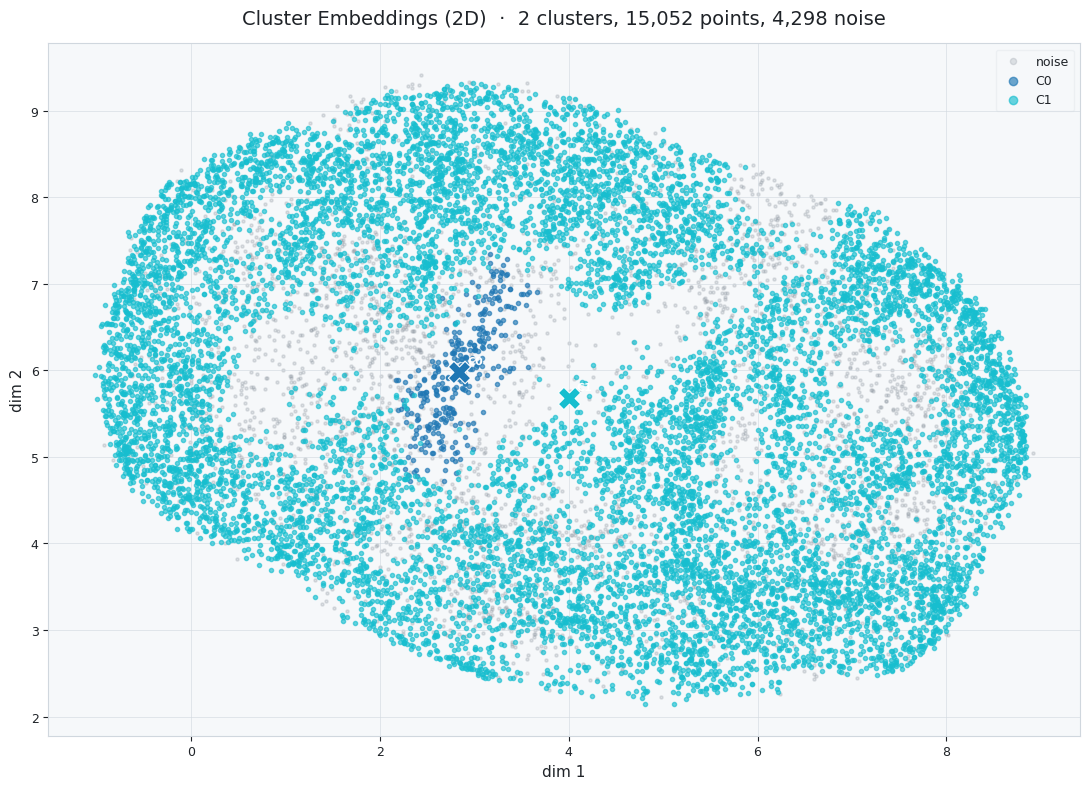

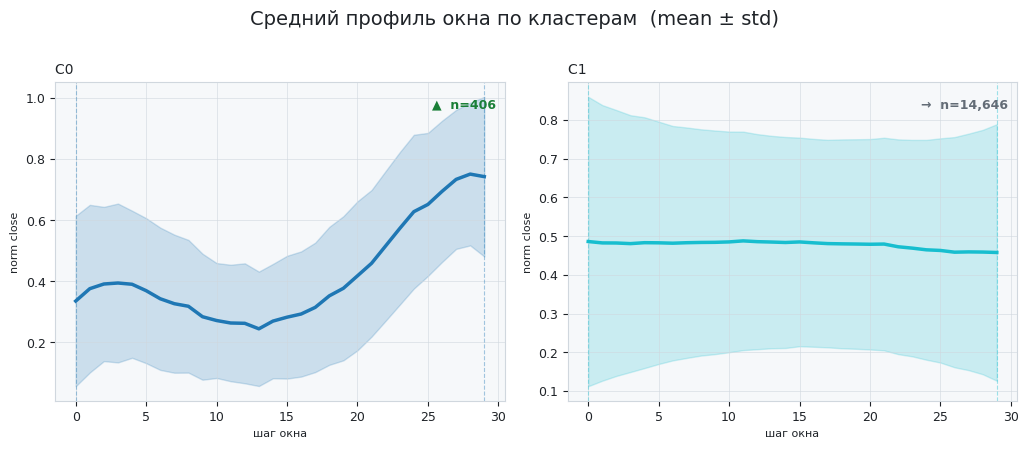

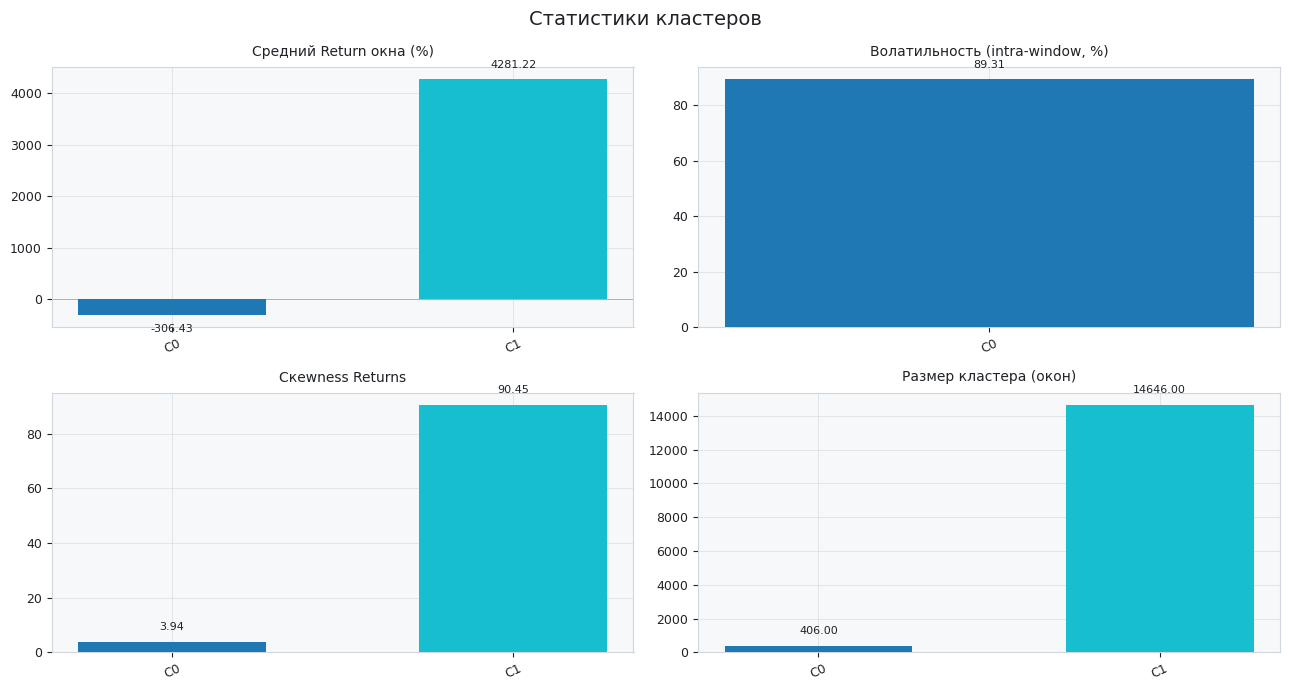

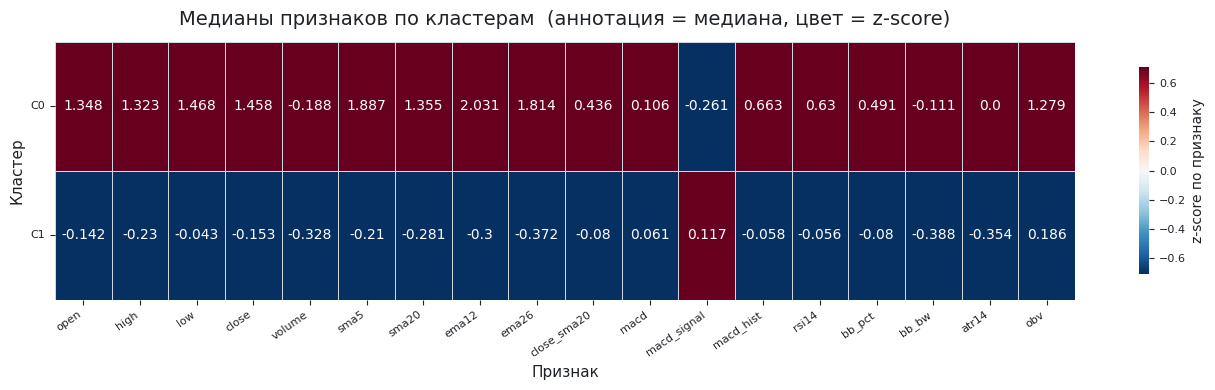

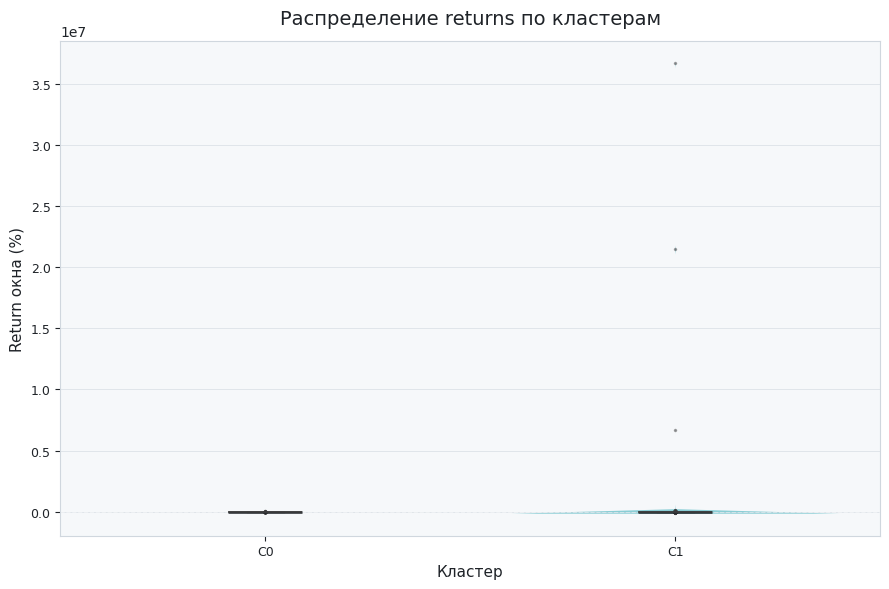

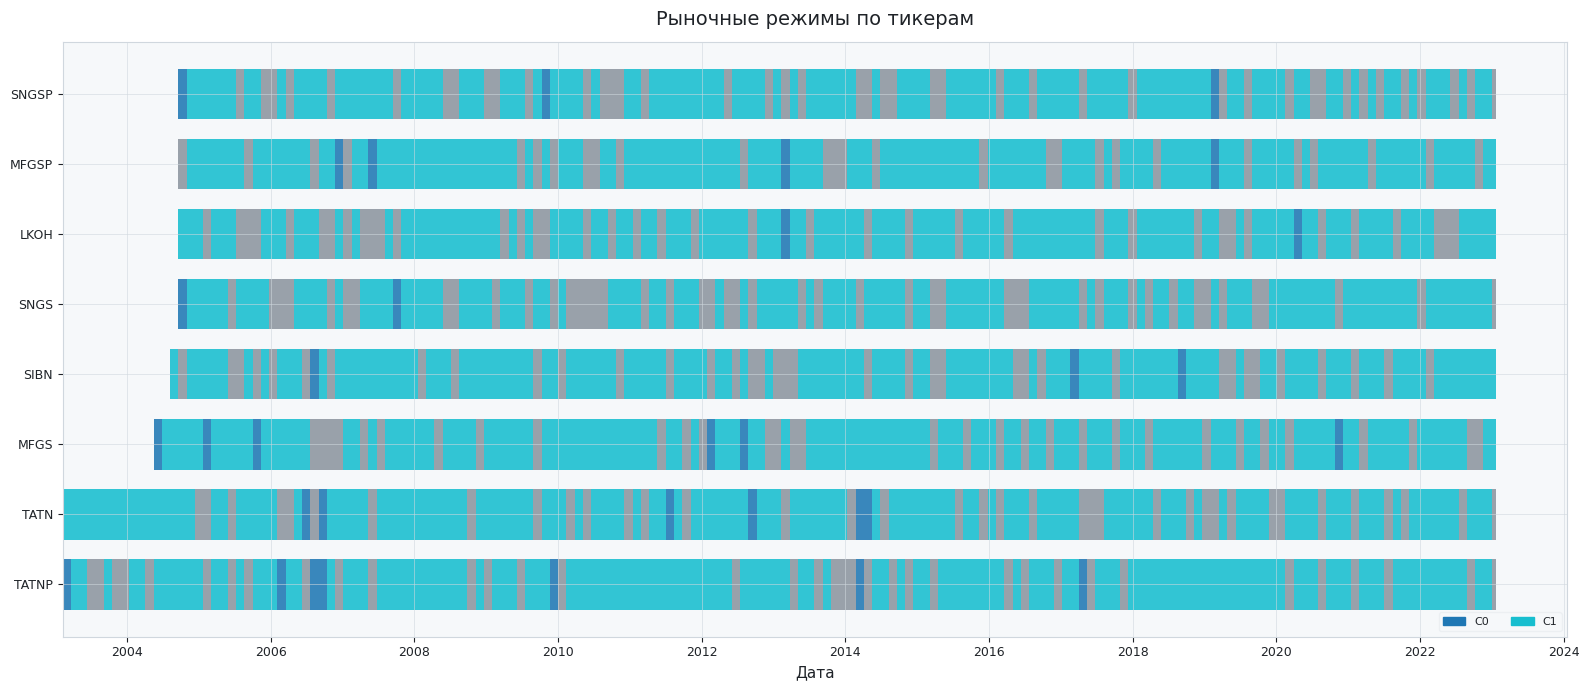

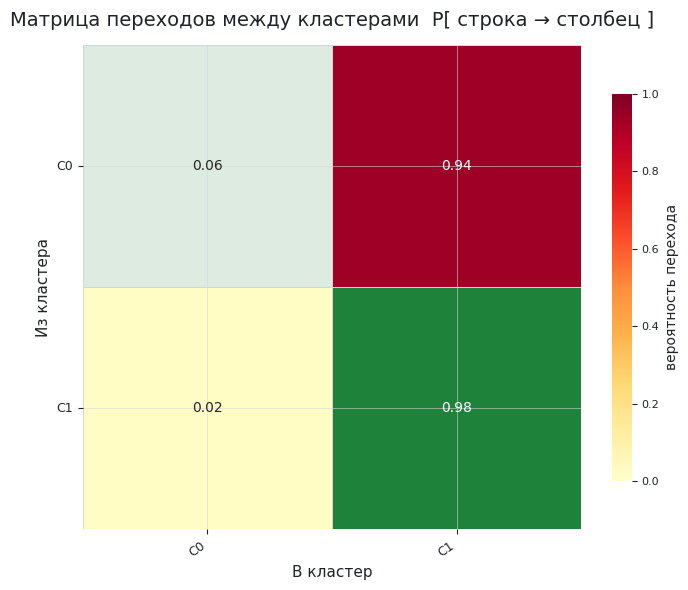

In [ ]:
# ── Все визуализации через ClusterAnalyzer ────────────────────────────────────
figs = analyzer.run_all(embeddings_2d=Z2_train, X_metrics=Z_train, aggregate_temporal=False)
plt.show()

In [ ]:
# Медианы признаков (для RegimeInterpreter в cell 9)
print("Медианы признаков по кластерам:")
print(medians[FEATURE_COLS].round(4).to_string())

Медианы признаков по кластерам:
           open    high     low   close  volume    sma5   sma20   ema12   ema26  close_sma20    macd  macd_signal  macd_hist   rsi14  bb_pct   bb_bw   atr14     obv
cluster                                                                                                                                                             
0        1.3476  1.3228  1.4680  1.4575 -0.1880  1.8869  1.3552  2.0306  1.8141       0.4359  0.1062      -0.2610     0.6634  0.6302  0.4910 -0.1111  0.0002  1.2792
1       -0.1424 -0.2301 -0.0429 -0.1533 -0.3283 -0.2098 -0.2810 -0.3001 -0.3719      -0.0796  0.0613       0.1165    -0.0577 -0.0559 -0.0804 -0.3879 -0.3538  0.1862


In [ ]:
# Чтобы задать имена кластеров вручную после изучения тепловой карты признаков,
# передайте cluster_names при создании analyzer или обновите постфактум:
#
# analyzer._custom_names = {0: "Uptrend", 1: "Panic", 2: "Sideways", ...}
#
# После этого вызовите нужный plot-метод повторно, например:
# analyzer.plot_embeddings_2d(embeddings_2d=Z2_train)

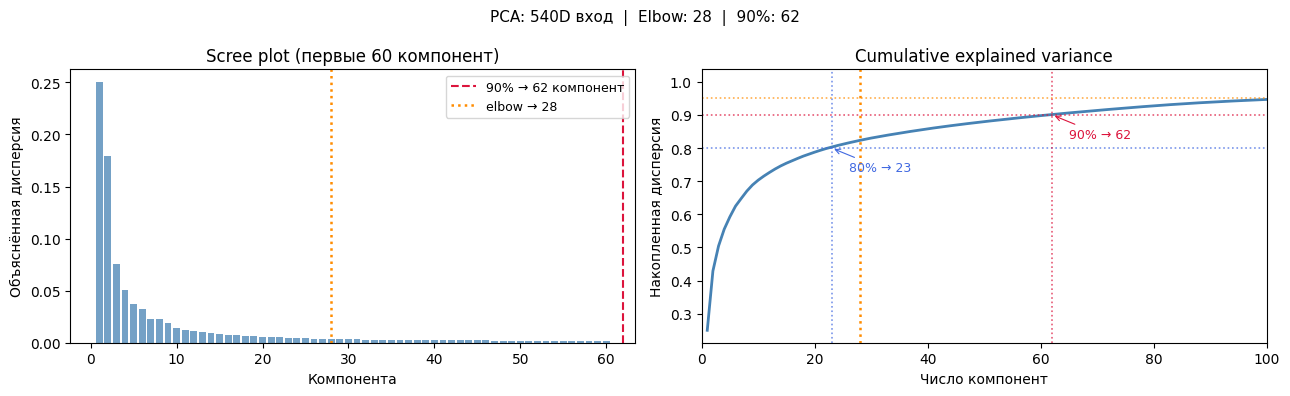

PCA рекомендации:
  Elbow (kneedle): 28
  80% дисперсии → 23 компонент
  90% дисперсии → 62 компонент
  95% дисперсии → 105 компонент
Алгоритмы: ['hdbscan']
UMAP-групп: 48  ×  (4 HDBSCAN) = 192 конфигураций
Каждая UMAP-группа запускается 3× для stability. ≈ 144 UMAP fits.



UMAP groups:   0%|          | 0/48 [00:00<?, ?group/s]

KeyboardInterrupt: 

In [ ]:
# ── Полный подбор гиперпараметров PCA → UMAP → HDBSCAN / KMeans ─────────────
#
# ClusterPipelineSearch перебирает все комбинации n_pca × umap_params ×
# cluster_params, оценивает silhouette, Davies-Bouldin, stability ARI и
# downstream RMSE, применяет жёсткие фильтры и ранжирует по composite score.
#
# Примерное время: ~3–5 мин на предложенном grid (≈ 48 UMAP fits).
# Для быстрого теста уменьши grid (см. комментарий ниже).

from clustering.pipeline_search import pca_analysis, ClusterPipelineSearch

# ── Шаг 1: анализ PCA (рекомендует n_pca) ────────────────────────────────────
pca_res = pca_analysis(F_train_sc, random_state=RANDOM_STATE)

# ── Шаг 2: Grid search ───────────────────────────────────────────────────────
# Полный grid — закомментируй строки для ускорения
searcher = ClusterPipelineSearch(
    n_pca_values             = [pca_res["k80"], pca_res["k90"]],   # из PCA-анализа
    n_neighbors_values       = [10, 20, 30, 50],
    min_dist_values          = [0.0, 0.1],
    n_components_umap_values = [5, 10, 15],
    algos                    = ["hdbscan"],             # ["hdbscan"], ["kmeans"] или оба
    min_cluster_size_values  = [50, 100, 200, 500],    # HDBSCAN
    n_clusters_values        = [3, 4, 5, 6, 8],        # KMeans (не используется при algos=["hdbscan"])
    # Жёсткие фильтры
    min_n_clusters    = 3,
    max_n_clusters    = 8,
    max_noise_ratio   = 0.20,
    min_stability_ari = 0.70,
    min_cluster_points= 300,
    # Веса composite score
    w_silhouette  = 0.4,
    w_downstream  = 0.4,
    w_stability   = 0.2,
    sil_sample    = 10_000,
    save_path     = "../../results/pipeline_search.csv",   # чекпоинт после каждой UMAP-группы
    random_state  = RANDOM_STATE,
)

searcher.run(F_train_sc, y_train)

# ── Шаг 3: Итоги ─────────────────────────────────────────────────────────────
searcher.summary()
print()
print("── Топ-3 конфигурации ─────────────────────────────────────────────────")
display(searcher.top_k(3))